<a href="https://colab.research.google.com/github/Abiraminagarajan-19/AI-crop-recommendation-system/blob/main/project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pickle
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
data=pd.read_csv(r"/content/student_performance_dataset.csv")

In [ ]:
data.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [ ]:
data.describe()

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,19.030333,3.988767,3.511667,69.926333,74.558000,2.949422,0.493000,61.961667,1.538933,...,3.500333,1.054167,5.552000,5.467667,5.556667,5.546333,5.446000,5.535000,5.512333,54.795667
std,866.169729,2.553217,1.503377,2.297743,17.562794,14.473048,1.510306,0.500034,33.125156,0.925619,...,2.274436,0.725919,2.906564,2.856047,2.865809,2.864132,2.890421,2.837157,2.860287,18.691309
min,0.000000,15.000000,0.500000,0.000000,40.000000,50.000000,0.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,749.750000,17.000000,2.900000,1.000000,55.000000,62.000000,1.900000,0.000000,32.000000,0.900000,...,2.000000,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,42.000000
50%,1499.500000,19.000000,4.000000,4.000000,70.000000,74.000000,2.900000,0.000000,62.000000,1.500000,...,3.000000,1.000000,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000,55.000000
75%,2249.250000,21.000000,5.000000,6.000000,85.000000,87.000000,4.000000,1.000000,91.000000,2.100000,...,5.000000,1.600000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,67.000000
max,2999.000000,23.000000,8.800000,7.000000,100.000000,100.000000,8.900000,1.000000,119.000000,5.000000,...,7.000000,3.900000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


In [ ]:
list(data)

['student_id',
 'age',
 'gender',
 'city_type',
 'study_hours_per_day',
 'deep_work_sessions',
 'assignment_completion_rate',
 'attendance_percentage',
 'social_media_hours',
 'doomscrolling_before_sleep',
 'notification_distractions',
 'ai_tool_usage_hours',
 'gaming_hours',
 'stress_level',
 'motivation_level',
 'focus_score',
 'procrastination_index',
 'mental_state',
 'sleep_hours',
 'caffeine_intake',
 'physical_activity_hours',
 'internet_quality',
 'family_support',
 'financial_stress',
 'learning_style',
 'career_goal',
 'productivity_after_midnight',
 'revision_efficiency',
 'burnout_risk',
 'consistency_score',
 'final_exam_score',
 'performance_category']

In [ ]:
data['consistency_score'].unique()

array([ 3,  6,  1, 10,  9,  2,  7,  8,  5,  4])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

In [ ]:
data.groupby(['career_goal']).count()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,internet_quality,family_support,financial_stress,learning_style,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
career_goal,,,,,,,,,,,,,,,,,,,,,
Arts,623,623,623,623,623,623,623,623,611,623,...,623,623,623,623,623,623,623,623,623,623
Business,582,582,582,582,582,582,582,582,573,582,...,582,582,582,582,582,582,582,582,582,582
Engineering,592,592,592,592,592,592,592,592,578,592,...,592,592,592,592,592,592,592,592,592,592
Medical,630,630,630,630,630,630,630,630,620,630,...,630,630,630,630,630,630,630,630,630,630
Research,573,573,573,573,573,573,573,573,558,573,...,573,573,573,573,573,573,573,573,573,573


In [ ]:
dataa=data.drop(['career_goal'],axis=1)

In [ ]:
numeric_dataa = dataa.select_dtypes(include=['number'])
cor_mat=numeric_dataa.corr()
cor_mat

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
student_id,1.000000,0.006148,-0.003255,0.006041,0.001543,-0.003225,-0.001515,-0.002465,0.017464,-0.019183,...,0.003120,-0.009251,-0.021342,0.029552,-0.015130,0.055625,-0.013122,0.027454,-0.008906,-0.025445
age,0.006148,1.000000,-0.005097,0.016621,-0.026400,0.001789,-0.005033,-0.010150,-0.019041,-0.038637,...,-0.003992,-0.005133,0.013514,-0.008256,0.034331,0.016975,-0.012723,-0.007120,0.017687,0.000172
study_hours_per_day,-0.003255,-0.005097,1.000000,-0.023192,-0.009388,0.005088,-0.007316,-0.031398,-0.009896,-0.001972,...,0.011045,-0.009204,0.001374,-0.005711,0.007465,-0.004374,-0.001816,0.010048,0.026812,0.317229
deep_work_sessions,0.006041,0.016621,-0.023192,1.000000,-0.017938,-0.034397,-0.029299,-0.015891,-0.004798,0.034074,...,0.008039,0.003789,-0.012398,0.006256,-0.011570,0.032345,-0.014239,-0.022875,0.000080,0.086185
assignment_completion_rate,0.001543,-0.026400,-0.009388,-0.017938,1.000000,-0.004436,0.006491,0.004441,0.019573,-0.000135,...,-0.011031,0.002429,0.014044,-0.007795,0.015277,0.025108,-0.004811,0.007296,-0.029948,0.159037
attendance_percentage,-0.003225,0.001789,0.005088,-0.034397,-0.004436,1.000000,-0.006399,-0.012039,0.013282,0.021479,...,-0.017074,0.015873,-0.006357,0.002897,0.017406,0.001998,0.011019,-0.004520,-0.010243,0.172020
social_media_hours,-0.001515,-0.005033,-0.007316,-0.029299,0.006491,-0.006399,1.000000,0.002271,0.002801,-0.011195,...,-0.040984,-0.017644,-0.014771,0.033438,-0.027225,-0.004108,0.011296,-0.013405,-0.047844,-0.172449
doomscrolling_before_sleep,-0.002465,-0.010150,-0.031398,-0.015891,0.004441,-0.012039,0.002271,1.000000,0.020890,-0.028300,...,-0.004103,-0.015536,0.006101,-0.002493,-0.005191,-0.022590,-0.001992,0.029553,0.000060,-0.138240
notification_distractions,0.017464,-0.019041,-0.009896,-0.004798,0.019573,0.013282,0.002801,0.020890,1.000000,0.004092,...,-0.014563,-0.000291,-0.025190,0.030367,0.013695,-0.000612,0.011723,-0.008872,-0.009203,-0.031477
ai_tool_usage_hours,-0.019183,-0.038637,-0.001972,0.034074,-0.000135,0.021479,-0.011195,-0.028300,0.004092,1.000000,...,0.000168,0.018045,-0.005574,-0.003081,-0.022315,-0.033005,-0.004959,-0.009610,-0.017650,-0.003776


<Axes: >

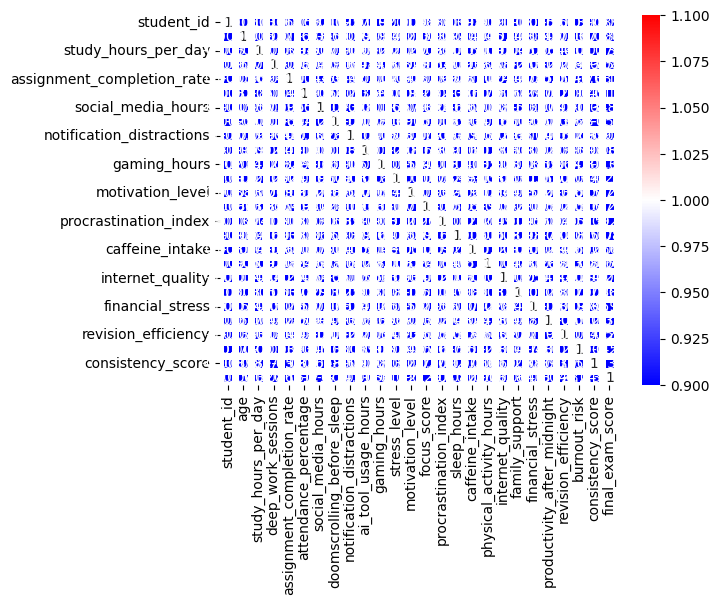

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cor_mat,vmax=1,vmin=1,annot=True,linewidths=5,cmap='bwr')

In [ ]:
data2=data.drop(['student_id','age'],axis=1)

In [ ]:
data2.shape

(3000, 30)

In [ ]:
data2.head(3)

,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,Female,Semi-Urban,3.2,7,100,70,3.8,0,107,0.6,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,Female,Semi-Urban,3.9,2,46,70,2.6,1,93,1.5,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,Female,Urban,4.3,7,54,57,4.3,1,82,0.5,...,1,9,Visual,Engineering,7,9,8,1,34,Low


In [ ]:
data2=pd.get_dummies(data2,dtype=int)

In [ ]:
data2.shape

(3000, 45)

In [ ]:
data2.head(8)

,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,stress_level,...,learning_style_Reading,learning_style_Visual,career_goal_Arts,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research,performance_category_High,performance_category_Low,performance_category_Medium
0,3.2,7,100,70,3.8,0,107,0.6,1.8,8,...,0,0,0,0,1,0,0,0,1,0
1,3.9,2,46,70,2.6,1,93,1.5,1.1,4,...,0,0,0,1,0,0,0,0,0,1
2,4.3,7,54,57,4.3,1,82,0.5,0.0,2,...,0,1,0,0,1,0,0,0,1,0
3,5.3,1,78,90,1.7,0,27,1.4,3.8,8,...,1,0,0,0,0,1,0,0,0,1
4,4.1,3,100,81,2.6,0,8,1.3,2.5,4,...,0,1,0,0,0,1,0,1,0,0
5,3.5,2,96,62,0.0,0,41,1.8,0.4,8,...,1,0,0,0,0,1,0,0,0,1
6,4.2,1,67,72,2.4,1,105,2.7,0.0,2,...,0,0,0,1,0,0,0,0,0,1
7,7.3,0,99,55,4.2,1,63,1.9,3.1,3,...,0,0,0,0,0,1,0,1,0,0


In [ ]:
x=data2.drop(['final_exam_score'],axis=1)
y=data2['final_exam_score']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
x_train.shape

(2250, 44)

In [ ]:
y_train.shape

(2250,)

In [ ]:
from sklearn.linear_model import LinearRegression
reg_imputed=LinearRegression()
reg_imputed.fit(x_train_imputed,y_train)

LinearRegression()

In [ ]:
ypred=reg_imputed.predict(x_test_imputed)

In [ ]:
ypred

array([ 40.26881146,  62.1151639 ,  59.58943492,  53.94546676,
        36.78946724,  57.68310758,  83.6916254 ,  44.53033406,
        77.25959163,  58.84334389,  35.95775647,  66.62001674,
        40.24280939,  59.22311901,  38.65541602,  54.95707087,
        56.87214331,  29.9891469 ,  59.21586855,  92.05462304,
        63.02190072,  32.54529059,  63.68920613,  60.25529922,
        37.66525898,  66.26174221,  83.10676699,  65.7055286 ,
        53.64878529,  77.60445829,  40.11706071,  41.9300639 ,
        56.21391314,  37.3129703 ,  28.7576073 ,  45.87670615,
        36.09844201,  42.3784299 ,  63.15593985,  23.23917963,
        86.95666393,  68.62428775,  78.04784202,  57.56577441,
        64.8471871 ,  51.39589745,  56.84283756,  28.98281392,
        54.46916165,  34.13014172,  32.73434638,  22.2191378 ,
        67.84768003,  87.45968699,  53.02183152,  29.62845733,
        86.8468169 ,  54.33950916,  62.06905545,  59.48630048,
        55.70923605,  60.15933613,  35.28558568,  51.64

In [ ]:
y_test

,final_exam_score
1801,44
1190,72
1817,55
251,51
2505,44
...,...
195,29
1775,47
2841,53
1735,56


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.897865093605626

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape
mape_value = mape(y_test,ypred)
mape_value

139546614273239.69

In [ ]:
from sklearn.metrics import mean_squared_error
t=mean_squared_error(y_test,ypred)
print(t**.5)

5.864595434335145


In [ ]:
new = [new_sample_1, new_sample_2, new_sample_3]
final_exam_score=reg_imputed.predict(new)
final_exam_score

array([24.91825489, 24.91825489, 24.91825489])

In [ ]:
Results=pd.DataFrame(columns=['final_exam_score','predicted'])
Results['final_exam_score']=y_test
Results['predicted']=ypred
Results=Results.reset_index()
Results['perfomance_category']=Results.index
Results.head(10)

,index,final_exam_score,predicted,perfomance_category
0,1801,44,40.268811,0
1,1190,72,62.115164,1
2,1817,55,59.589435,2
3,251,51,53.945467,3
4,2505,44,36.789467,4
5,1117,51,57.683108,5
6,1411,88,83.691625,6
7,2113,44,44.530334,7
8,408,71,77.259592,8
9,2579,53,58.843344,9


[]

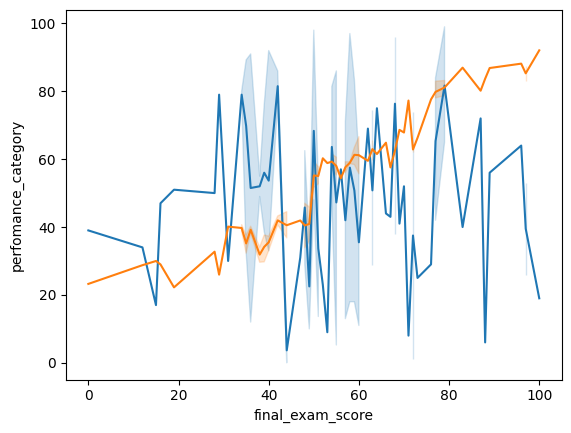

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x='final_exam_score',y='perfomance_category',data=Results.head(100))
sns.lineplot(x='final_exam_score',y='predicted',data=Results.head(100))
plt.plot()